In [3]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\cdaniels
['.anaconda', '.cisco', '.conda', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.ms-ad', '.virtual_documents', '3D Objects', 'anaconda_projects', 'AppData', 'Application Data', 'Assignment2_Regression.ipynb', 'Contacts', 'Cookies', 'Creative Cloud Files  cdaniels@nu.edu 21DD20F4638333C80A495E90@28a6211d638333b3495ebe.e', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{f762a9dc-b060-11ec-86f1-d880837ea3fa}.TM.blf', 'NTUSER.DAT{f762a9dc-b060-11ec-86f1-d880837ea3fa}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{f762a9dc-b060-11ec-86f1-d880837ea3fa}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'OneDrive - National University', 'Pictures', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'test.csv', 'train.csv', 'Videos']


Linear Regression RMSE: 2.023690349601809
                            OLS Regression Results                            
Dep. Variable:                  Rings   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.607
Method:                 Least Squares   F-statistic:                 1.242e+04
Date:                Tue, 24 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:01:23   Log-Likelihood:            -1.5266e+05
No. Observations:               72492   AIC:                         3.053e+05
Df Residuals:                   72482   BIC:                         3.054e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
co

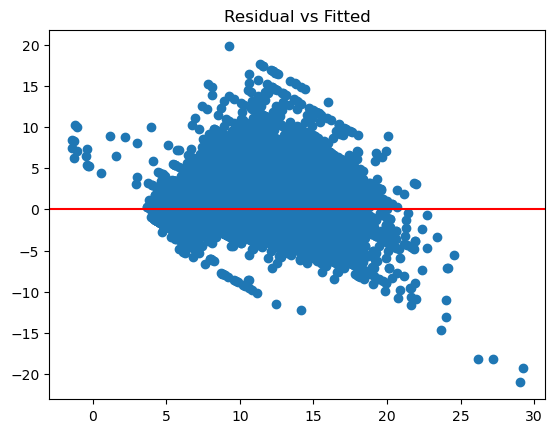

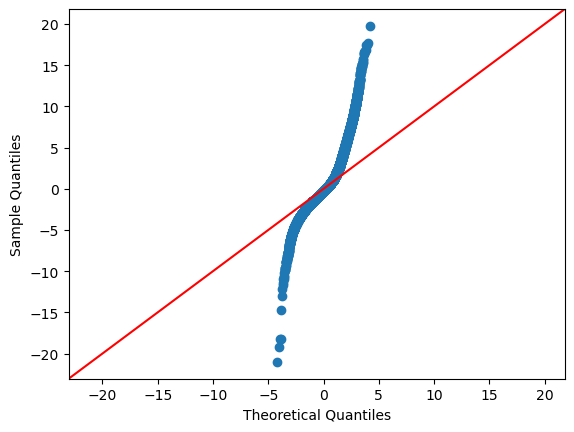

          feature         VIF
0          Length  935.544649
1        Diameter  967.666046
2          Height  100.027285
3    Whole weight  273.393736
4  Whole weight.1   80.606146
5  Whole weight.2   76.633740
6    Shell weight   72.071110
7           Sex_I    2.923818
8           Sex_M    2.116348
Durbin-Watson: 1.9952106000583598
Random Forest RMSE: 1.895515779933602
Submission file created.


In [10]:
# Assignment 2 – Regression Models
# DDS-8555 Predictive Analysis

# =========================
# Imports
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from scipy import stats

# =========================
# Load Data
# =========================
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# One-hot encode categorical variable
train = pd.get_dummies(train, columns=["Sex"], drop_first=True)
test = pd.get_dummies(test, columns=["Sex"], drop_first=True)

X = train.drop(["Rings", "id"], axis=1)
y = train["Rings"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# Model 1: Linear Regression
# =========================
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)
rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred))
print("Linear Regression RMSE:", rmse_lr)


# =========================
# Diagnostics (OLS)
# =========================

# Convert bool columns to 0/1 for statsmodels
X_train_ols = X_train.copy()
X_train_ols[X_train_ols.select_dtypes(include=["bool"]).columns] = (
    X_train_ols.select_dtypes(include=["bool"]).astype(int)
)

X_train_sm = sm.add_constant(X_train_ols)
model_sm = sm.OLS(y_train, X_train_sm).fit()
print(model_sm.summary())

# Residual Plot
residuals = model_sm.resid
fitted = model_sm.fittedvalues

plt.scatter(fitted, residuals)
plt.axhline(0, color='red')
plt.title("Residual vs Fitted")
plt.show()

# Q-Q Plot
sm.qqplot(residuals, line='45')
plt.show()

# VIF
X_for_vif = X_train.copy()
X_for_vif[X_for_vif.select_dtypes(include=["bool"]).columns] = (
    X_for_vif.select_dtypes(include=["bool"]).astype(int)
)

vif_data = pd.DataFrame()
vif_data["feature"] = X_for_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_for_vif.values, i)
                   for i in range(X_for_vif.shape[1])]
print(vif_data)

# Durbin-Watson
print("Durbin-Watson:", sm.stats.stattools.durbin_watson(residuals))

# =========================
# Model 2: Random Forest
# =========================
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
print("Random Forest RMSE:", rmse_rf)

# =========================
# Kaggle Submission Files
# =========================
final_model = rf
final_model.fit(X, y)

test_ids = test["id"]
X_test = test.drop(["id"], axis=1)

predictions = final_model.predict(X_test)

submission = pd.DataFrame({
    "Id": test_ids,
    "Rings": predictions
})

submission.to_csv("submission.csv", index=False)

print("Submission file created.")

In [5]:
print(train.columns.tolist())

['id', 'Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1', 'Whole weight.2', 'Shell weight', 'Rings', 'Sex_I', 'Sex_M']


In [16]:
# =========================
# Kaggle Submission - Linear Regression
# =========================

lr.fit(X, y)  # Train on full dataset

predictions_lr = lr.predict(X_test)

submission_lr = pd.DataFrame({
    "id": test_ids,   # lowercase
    "Rings": predictions_lr
})

submission_lr.to_csv("submission_linear.csv", index=False)
print("Linear submission file created.")

submission_rf = pd.DataFrame({
    "id": test_ids,   # lowercase
    "Rings": predictions
})

submission_rf.to_csv("submission_rf.csv", index=False)
print("RF submission file created.")

Linear submission file created.
RF submission file created.


In [17]:
import os
print([f for f in os.listdir() if f.endswith(".csv")])

['submission.csv', 'submission_linear.csv', 'submission_rf.csv', 'test.csv', 'train.csv']


In [18]:
submission.to_csv("submission_rf.csv", index=False)

In [19]:
import numpy as np
import pandas as pd

# Fit LR on full training data
lr.fit(X, y)

pred_lr = lr.predict(X_test)

# MSLE requires y_pred >= 0
pred_lr = np.clip(pred_lr, 0, None)

submission_linear = pd.DataFrame({
    "id": test_ids,
    "Rings": pred_lr
})

submission_linear.to_csv("submission_linear.csv", index=False)
print("Saved submission_linear.csv with non-negative predictions.")
print("Min prediction:", submission_linear["Rings"].min())

Saved submission_linear.csv with non-negative predictions.
Min prediction: 0.0


In [20]:
rf.fit(X, y)
pred_rf = rf.predict(X_test)
pred_rf = np.clip(pred_rf, 0, None)

submission_rf = pd.DataFrame({
    "id": test_ids,
    "Rings": pred_rf
})

submission_rf.to_csv("submission_rf.csv", index=False)
print("Saved submission_rf.csv with non-negative predictions.")
print("Min prediction:", submission_rf["Rings"].min())

Saved submission_rf.csv with non-negative predictions.
Min prediction: 3.1633333333333336


In [21]:
pd.read_csv("submission_linear.csv").describe()

,id,Rings
count,60411.000000,60411.000000
mean,120820.000000,9.703991
std,17439.297893,2.468965
min,90615.000000,0.000000
25%,105717.500000,7.905138
50%,120820.000000,9.663132
75%,135922.500000,11.172854
max,151025.000000,29.161230
